In [47]:
import os
import pandas as pd
import numpy as np
import src.feedbackFunctions as ff

In [45]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_dir = os.path.join(data_dir,'derivatives','fmriprep23','fmriprep')
nilearn_dir = os.path.join(data_dir,'derivatives','nilearn_glm')
output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['AA','UA']
hrf_delay = 3 # in seconds

In [ ]:
# Load subject-specific roi coordinates
roi_ss_coords = pd.read_csv(os.path.join(nilearn_dir,'group','roi_ss_matrix.txt'), sep='\t', header=None,
                            names=['left_mt_x','left_mt_y','left_mt_z','right_mt_x','right_mt_y','right_mt_z',
                                   'left_v1_x','left_v1_y','left_v1_z','right_v1_x','right_v1_y','right_v1_z'])

# add new column with the subject names
roi_ss_coords['subject'] = subject_list
roi_labels = ['hMT+ L', 'hMT+ R', 'V1 L', 'V1 R']

In [ ]:
# Initialize matrix to store the timeseries of all subjects per tr
TC = np.zeros((len(subject_list), len(tr_list), len(run_list), max(n_volumes_list)))

In [ ]:
# Create combinations of subject, tr and run
C = []
for ss,subject in enumerate(subject_list):
    # extract x,y,z coordinates of this subject's hMT+ and V1 roi
    cluster_coords = [[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0]]
    cluster_coords[0] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,0:3].values[0].tolist()
    cluster_coords[1] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,3:6].values[0].tolist()
    cluster_coords[2] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,6:9].values[0].tolist()
    cluster_coords[3] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,9:12].values[0].tolist()

    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            C.append([subject, tr, run, cluster_coords, fmriprep_dir, data_dir])

C

In [ ]:
# open parallel pool and execute
from multiprocessing import Pool
pool = Pool(20)

results = pool.starmap(ff.execute,C)
pool.close()


In [ ]:
# create dataframe
df = pd.DataFrame()

df['subject'] = [x[0] for x in C]
df['tr'] = [x[1] for x in C]
df['run'] = [x[2] for x in C]
df['timecourse'] = results

# save dataframe
df.to_pickle(os.path.join(output_dir,'feedbackSimulator.pkl'))

# Load from here

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [93]:
# load dataframe
df = pd.read_pickle(os.path.join('..','data','feedbackSimulator.pkl'))
df

,subject,tr,run,timecourse
0,sub-01,0.50,AA,"[[-0.44485015, -0.40461138, -0.68043756, -0.51..."
1,sub-01,0.50,UA,"[[-0.61327916, -0.76063555, -0.60919625, -0.41..."
2,sub-01,0.75,AA,"[[-0.022848858, -0.21764947, -0.26108494, -0.1..."
3,sub-01,0.75,UA,"[[0.29615146, 0.14547643, -0.36369002, -0.2859..."
4,sub-01,1.00,AA,"[[-0.1778471, -0.26660693, -0.23488899, -0.255..."
...,...,...,...,...
115,sub-23,0.75,UA,"[[-0.07604886, 0.053525686, 0.10802818, 0.1234..."
116,sub-23,1.00,AA,"[[-0.011512194, 0.12470216, 0.013986787, 0.086..."
117,sub-23,1.00,UA,"[[0.077241324, 0.12393124, 0.12205705, 0.04963..."
118,sub-23,2.50,AA,"[[0.03980456, -0.00043835002, -0.04854366, -0...."


In [96]:
# add a new column to df with the data in df['timecourse'].loc[ii][:,0]
df['left_mt'] = [x[:,0] for x in df['timecourse']]
df['right_mt'] = [x[:,1] for x in df['timecourse']]
df['left_v1'] = [x[:,2] for x in df['timecourse']]
df['right_v1'] = [x[:,3] for x in df['timecourse']]

In [101]:

t = df[df['tr']==0.5]['left_mt']
# calculate average of t
t_avg = np.mean(t.tolist(), axis=0)
# calculate standard deviation of t
t_std = np.std(t.tolist(), axis=0)


t_std.shape

(780,)

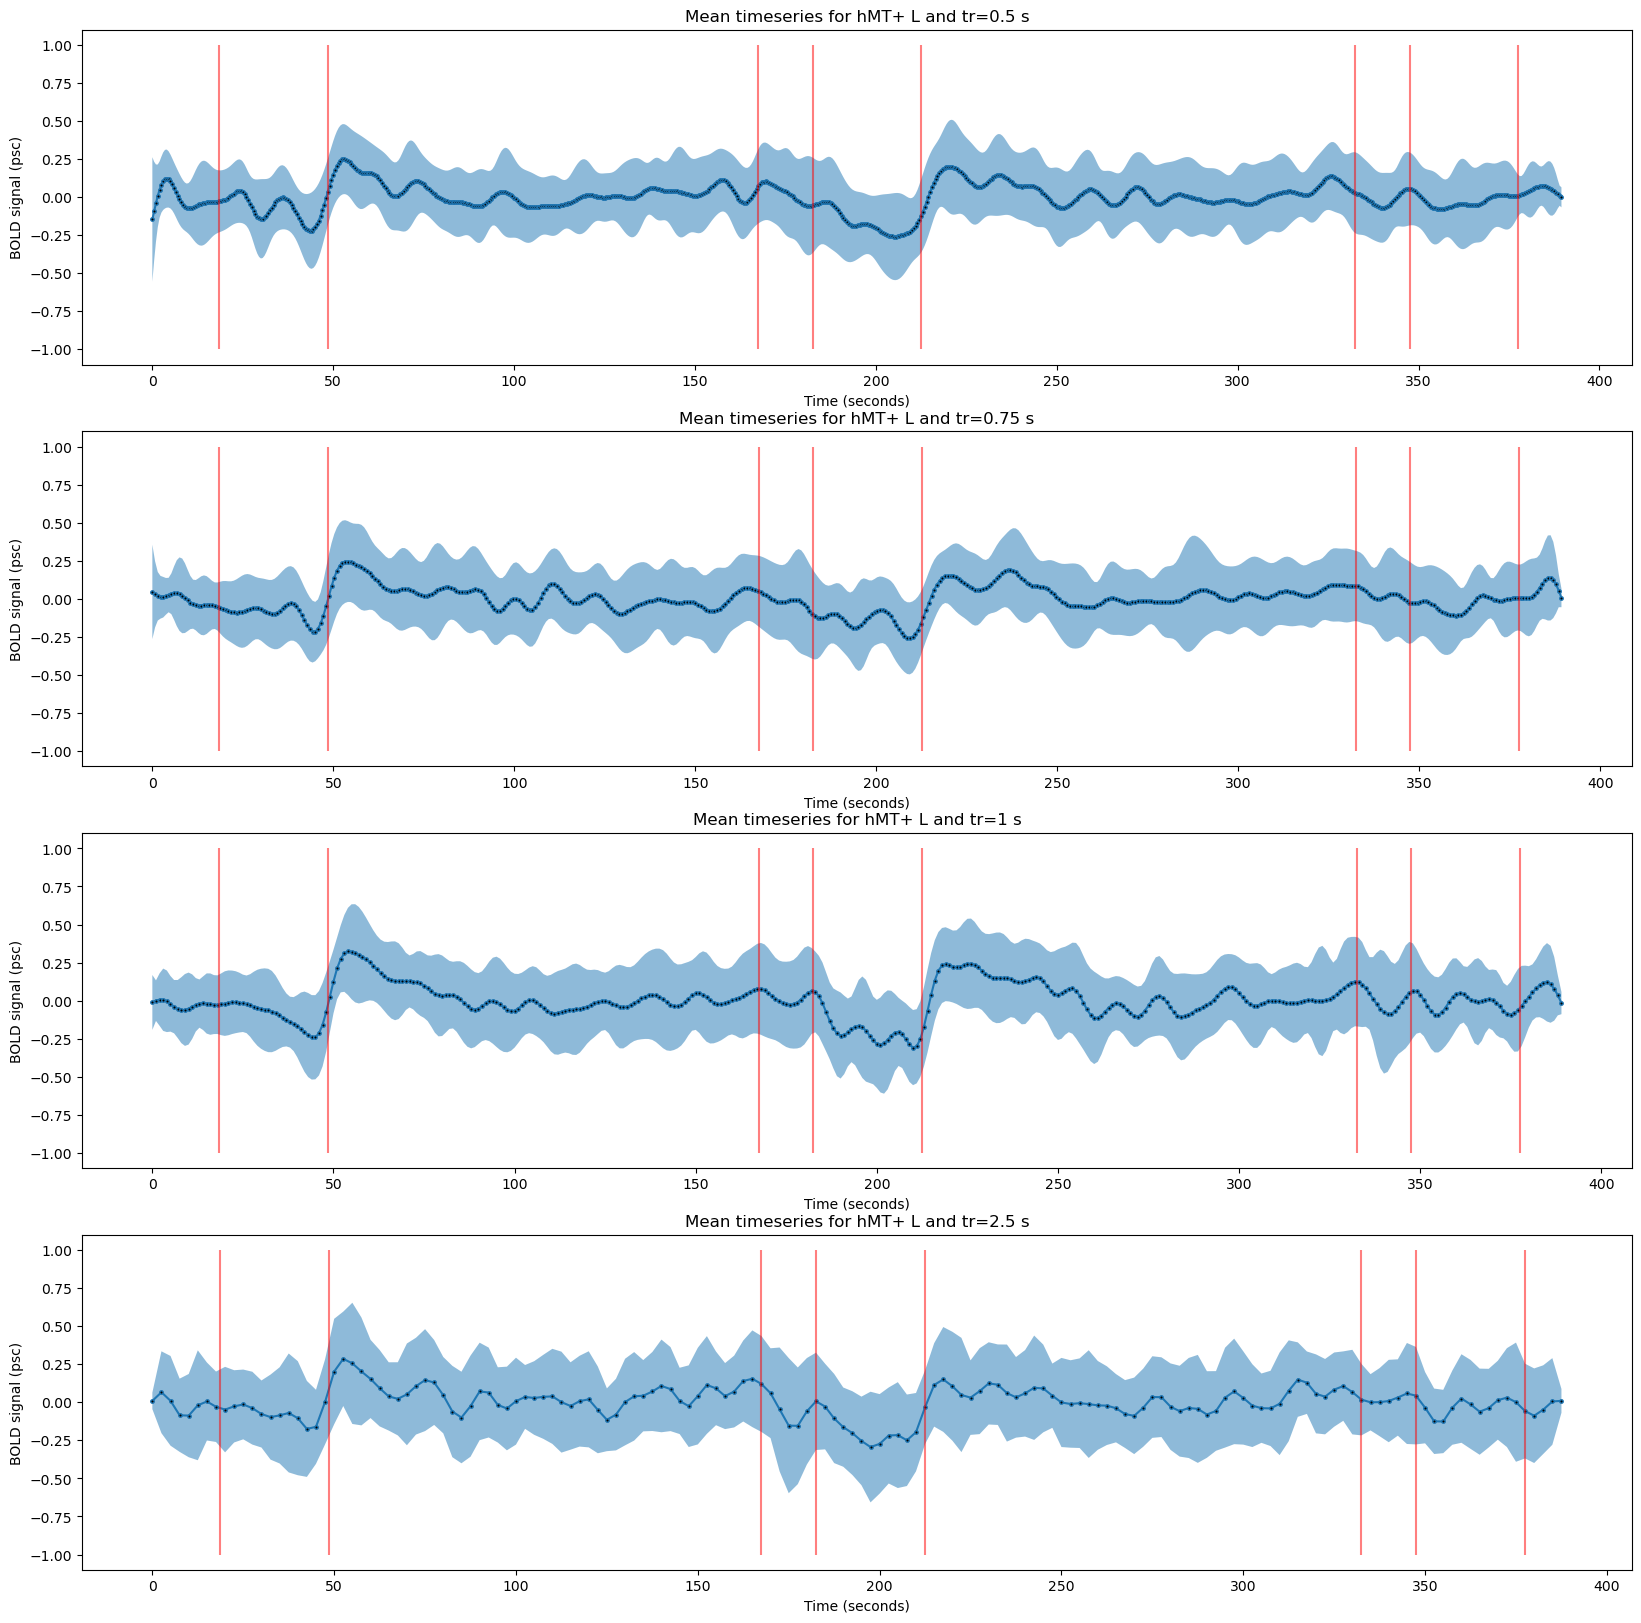

In [104]:
hrf_delay = 3 # in seconds
tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['AA','UA']
roi_labels = ['hMT+ L', 'hMT+ R', 'V1 L', 'V1 R']

verticalMarkers = np.array([15.5,45.5,164.5,179.5,209.5,329.5,344.5,374.5]) + hrf_delay # these mark the change of condition (including hrf_delay)

# plot mean timeseries for each tr for a single ROI
f, axs = plt.subplots(4, 1, figsize=(20, 20))
roi_name = 'left_mt'

for tr_idx,tr in enumerate(tr_list):
    
    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, n_volumes_list[tr_idx]*tr, tr)

    # plot mean and std timeseries across subjects
    data_aux = df[df['tr']==tr][roi_name]
    data_to_plot_mean = np.mean(data_aux.tolist(), axis=0)
    data_to_plot_std =  np.std(data_aux.tolist(), axis=0)

    axs[tr_idx].plot(time_vector, data_to_plot_mean, linestyle='-', marker='.', markersize=5, markerfacecolor='black')
    axs[tr_idx].fill_between(time_vector, data_to_plot_mean-data_to_plot_std, data_to_plot_mean+data_to_plot_std, alpha=0.5)
    axs[tr_idx].vlines(verticalMarkers, ymin=-1, ymax=1, color='red', alpha=0.5)
    axs[tr_idx].set_title(f"Mean timeseries for {roi_labels[roi_idx]} and tr={tr} s")
    axs[tr_idx].set_xlabel('Time (seconds)')
    axs[tr_idx].set_ylabel('BOLD signal (psc)')

## Events file and PSC to static

In [133]:
# Load sample events file per TR for sub-01
run_type = 'UA'
active_cond_name = 'Ambiguous' if run_type=='AA' else 'Unambiguous'

static_events_indexes_arr = np.zeros((len(tr_list), 500))
active_events_indexes_arr = np.zeros((len(tr_list), 500))

for tr_idx,tr in enumerate(tr_list):

    task_label = f'task-{run_type}_acq-{round(tr*1000):04}_run-1'
    events_file = os.path.join(data_dir, 'sub-01', 'func', f'sub-01_{task_label}_events.tsv')

    static_events_indexes, active_events_indexes = ff.read_events(events_file,hrf_delay,tr,active_cond_name)

    # save to array
    static_events_indexes_arr[tr_idx,:len(static_events_indexes)] = static_events_indexes
    active_events_indexes_arr[tr_idx,:len(active_events_indexes)] = active_events_indexes

verticalMarkers = np.array([15.5,45.5,164.5,179.5,209.5,329.5,344.5,374.5]) + hrf_delay # these mark the change of condition (including hrf_delay)

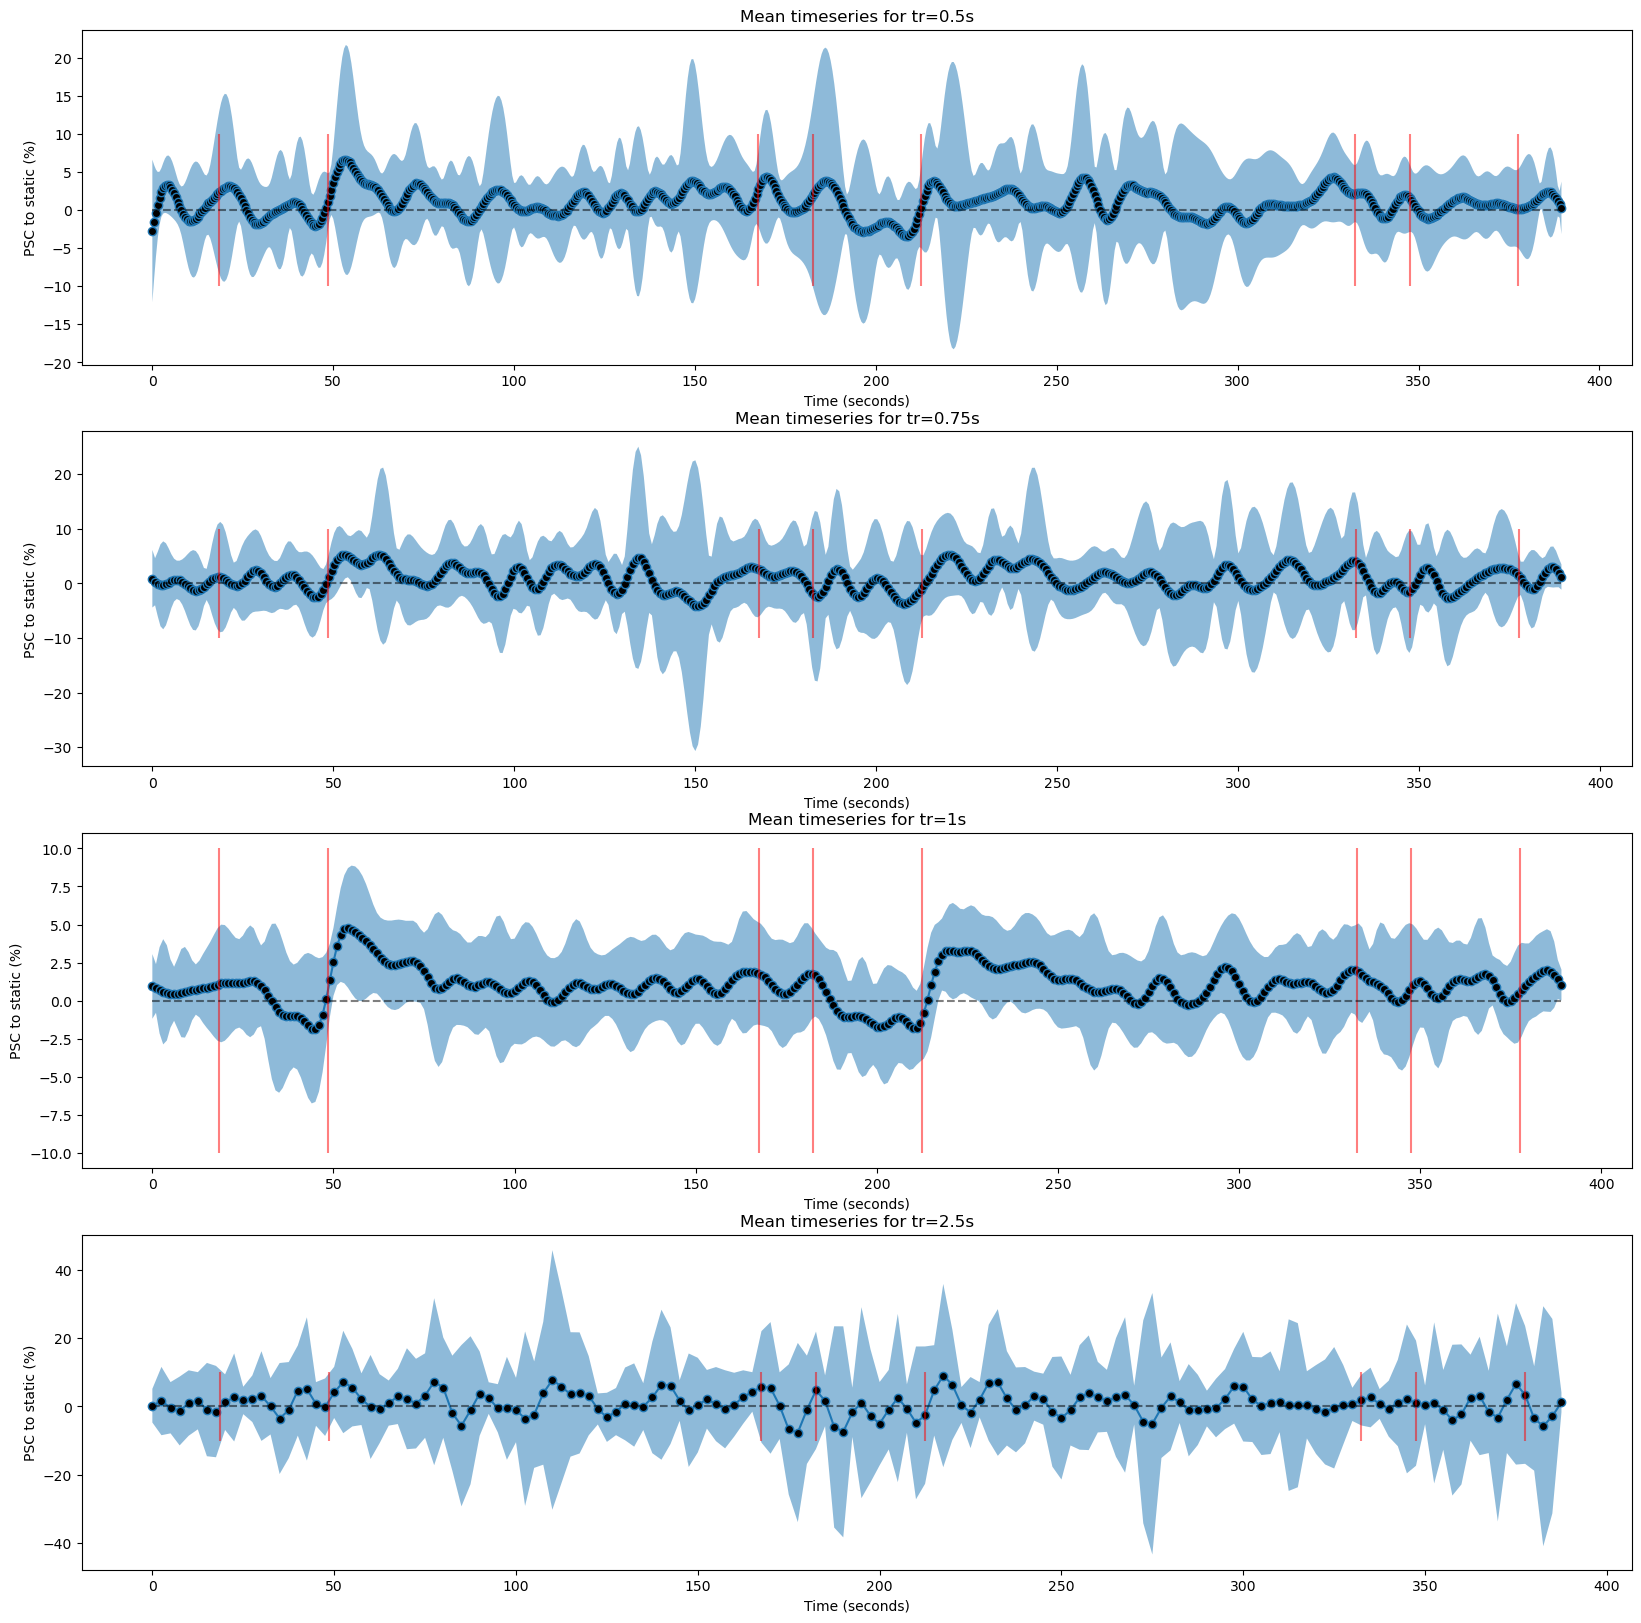

In [136]:
# plot mean PSC to static timeseries for each tr
roi_name = 'left_mt'
f_psc, axs_psc = plt.subplots(4, 1, figsize=(20, 20))

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros
    static_events_indexes_aux = static_events_indexes_arr[tr_idx,static_events_indexes_arr[tr_idx,:] > 0]
    
    time_series = df[df['tr']==tr][roi_name]
    time_series = np.array(time_series.tolist()) # convert time_series to numpy array
    time_series_static = time_series[:,static_events_indexes_aux.astype(int)]

    # calculate mean of each row
    m = time_series_static.mean(axis=1)

    # substrat m from time_series and divide by abs(m)
    time_series_psc = (time_series - m[:,None]) / abs(m[:,None])

    time_series_mean = time_series_psc.mean(axis=0)
    time_series_std = time_series_psc.std(axis=0)
    
    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, n_volumes_list[tr_idx]*tr, tr)

    # plot mean and std timeseries
    axs_psc[tr_idx].plot(time_vector, time_series_mean, marker = 'o', markerfacecolor = 'black', linestyle='-')
    axs_psc[tr_idx].fill_between(time_vector, time_series_mean-time_series_std, time_series_mean+time_series_std, alpha=0.5)
    axs_psc[tr_idx].vlines(verticalMarkers, ymin=-10, ymax=10, color='red', alpha=0.5)
    axs_psc[tr_idx].hlines(0, xmin=0, xmax=time_vector[-1], color='black', alpha=0.5, linestyle='--')
    axs_psc[tr_idx].set_title('Mean timeseries for tr='+str(tr)+'s')
    #axs_psc[tr_idx].set_ylim([-5, 20])
    axs_psc[tr_idx].set_xlabel('Time (seconds)')
    axs_psc[tr_idx].set_ylabel('PSC to static (%)')

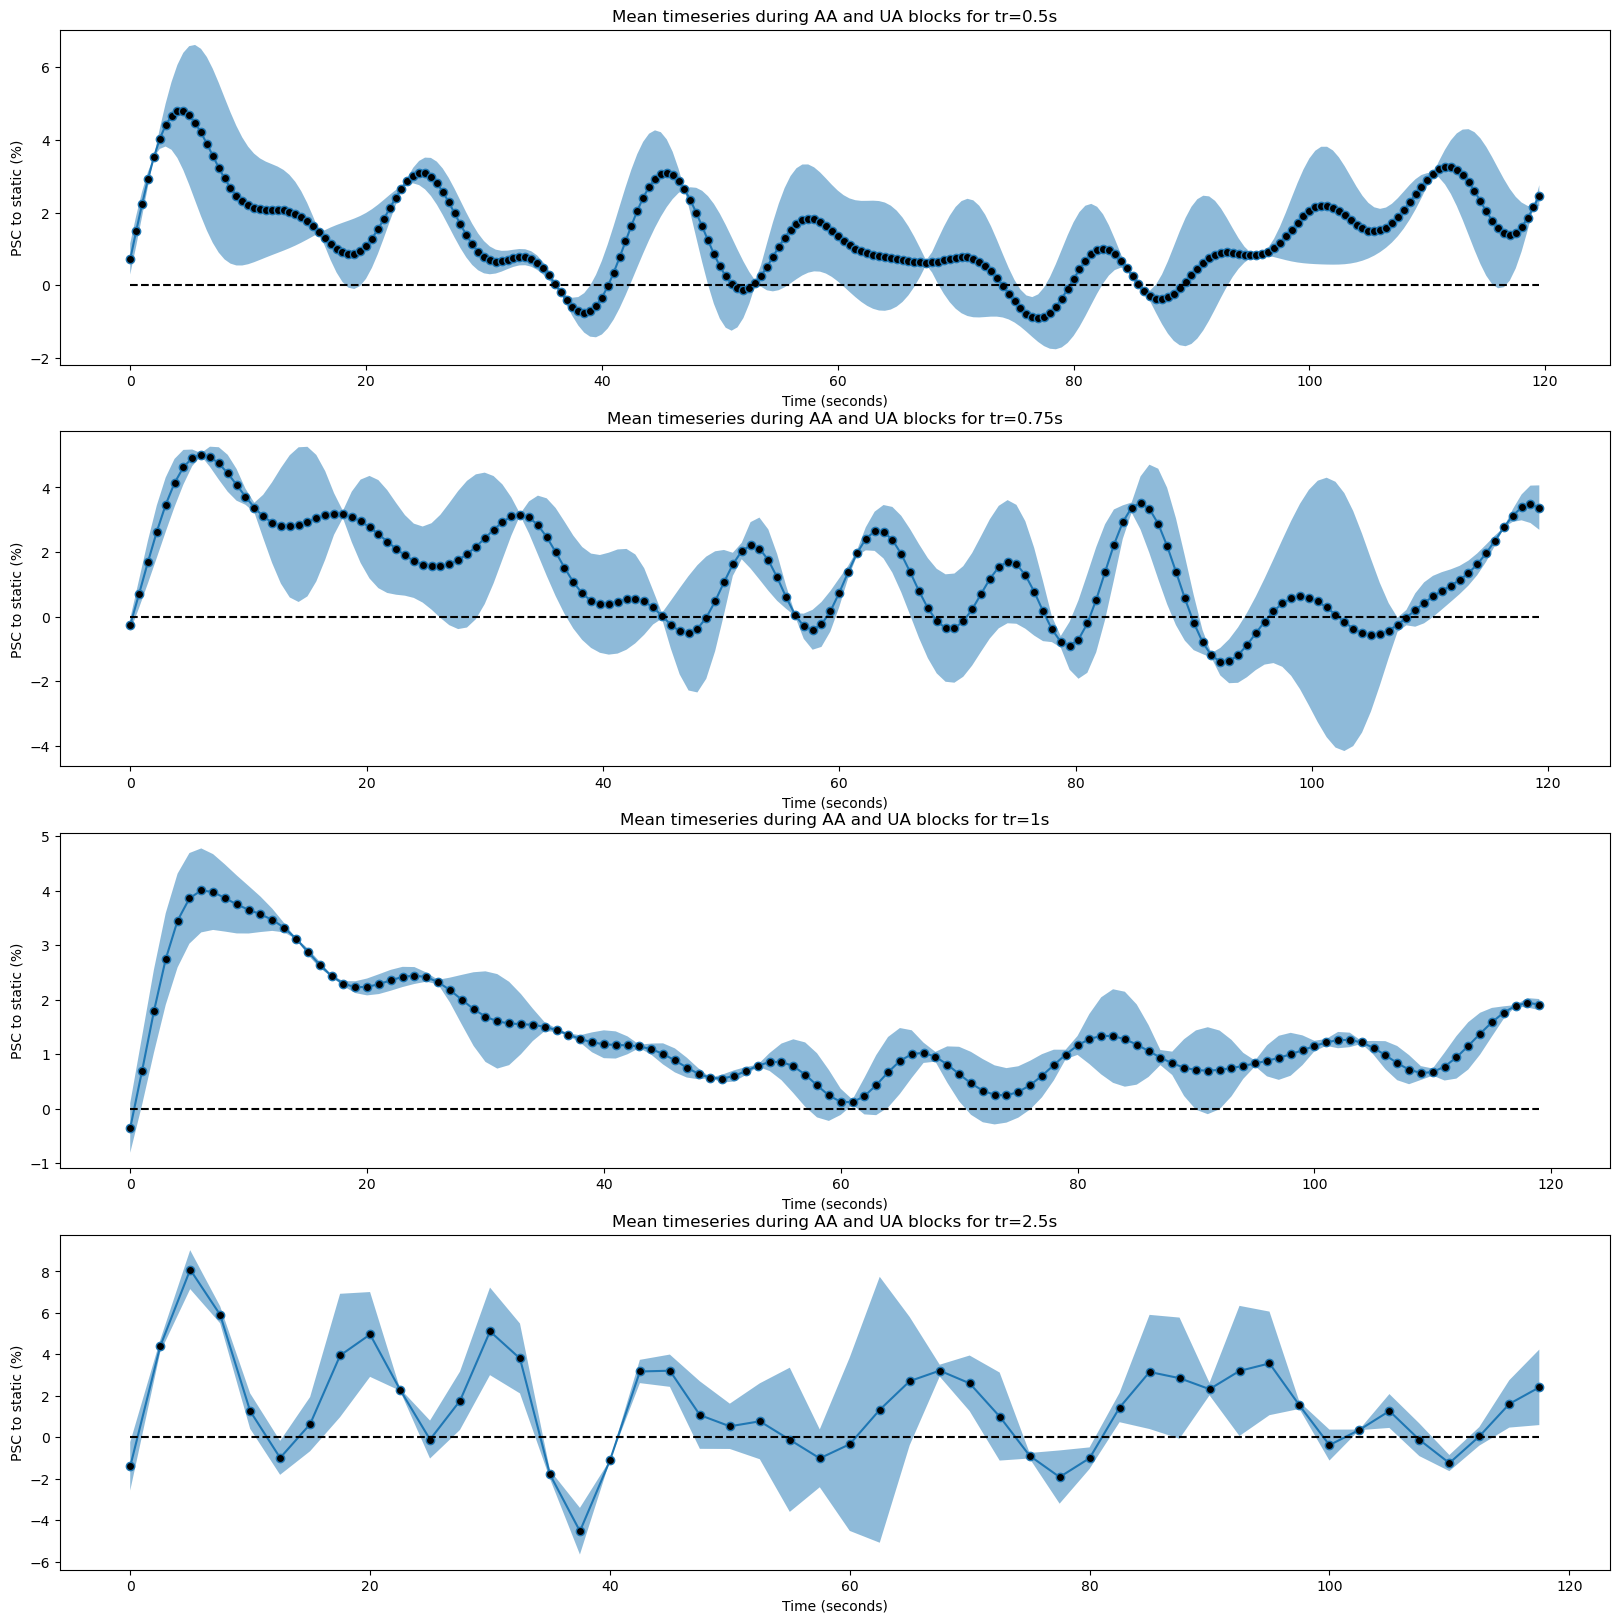

In [140]:
# plot ERA with mean PSC to static timeseries for each tr
f_psc, axs_psc = plt.subplots(4, 1, figsize=(20, 20))

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros
    static_events_indexes_aux = static_events_indexes_arr[tr_idx,static_events_indexes_arr[tr_idx,:] > 0]
    active_events_indexes_aux = active_events_indexes_arr[tr_idx,active_events_indexes_arr[tr_idx,:] > 0]

    time_series = df[df['tr']==tr][roi_name]
    time_series = np.array(time_series.tolist()) # convert time_series to numpy array
    time_series_static = time_series[:,static_events_indexes_aux.astype(int)]

    # calculate mean of each row
    m = time_series_static.mean(axis=1)

    # substrat m from time_series and divide by abs(m)
    time_series_psc = (time_series - m[:,None]) / abs(m[:,None])

    time_series_mean = time_series_psc.mean(axis=0)
    time_series_std = time_series_psc.std(axis=0)

    # estimate event related response
    time_series_mean_active = time_series_mean[active_events_indexes_aux.astype(int)]
    time_series_mean_active_length = time_series_mean_active.shape[0]//2

    # reshape time_series_mean_active to two columns with half the points each
    time_series_mean_active = time_series_mean_active.reshape((2,time_series_mean_active_length)).T

    # estimate mean and std
    time_series_mean_psc_active_mean = time_series_mean_active.mean(axis=1)
    time_series_mean_psc_active_std = time_series_mean_active.std(axis=1)

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, time_series_mean_active_length*tr, tr)

    data_to_plot_mean = time_series_mean_psc_active_mean
    data_to_plot_std = time_series_mean_psc_active_std

    # plot mean and std timeseries
    axs_psc[tr_idx].plot(time_vector, data_to_plot_mean, marker = 'o', markerfacecolor = 'black')
    axs_psc[tr_idx].fill_between(time_vector, data_to_plot_mean-data_to_plot_std, data_to_plot_mean+data_to_plot_std, alpha=0.5)
    axs_psc[tr_idx].hlines(0, 0, time_vector[-1], colors='k', linestyles='dashed')
    axs_psc[tr_idx].set_title('Mean timeseries during AA and UA blocks for tr='+str(tr)+'s')
    axs_psc[tr_idx].set_xlabel('Time (seconds)')
    axs_psc[tr_idx].set_ylabel('PSC to static (%)')
    #axs_psc[tr_idx].set_ylim([-1, 8])

Text(0, 0.5, 'Feedback signal')

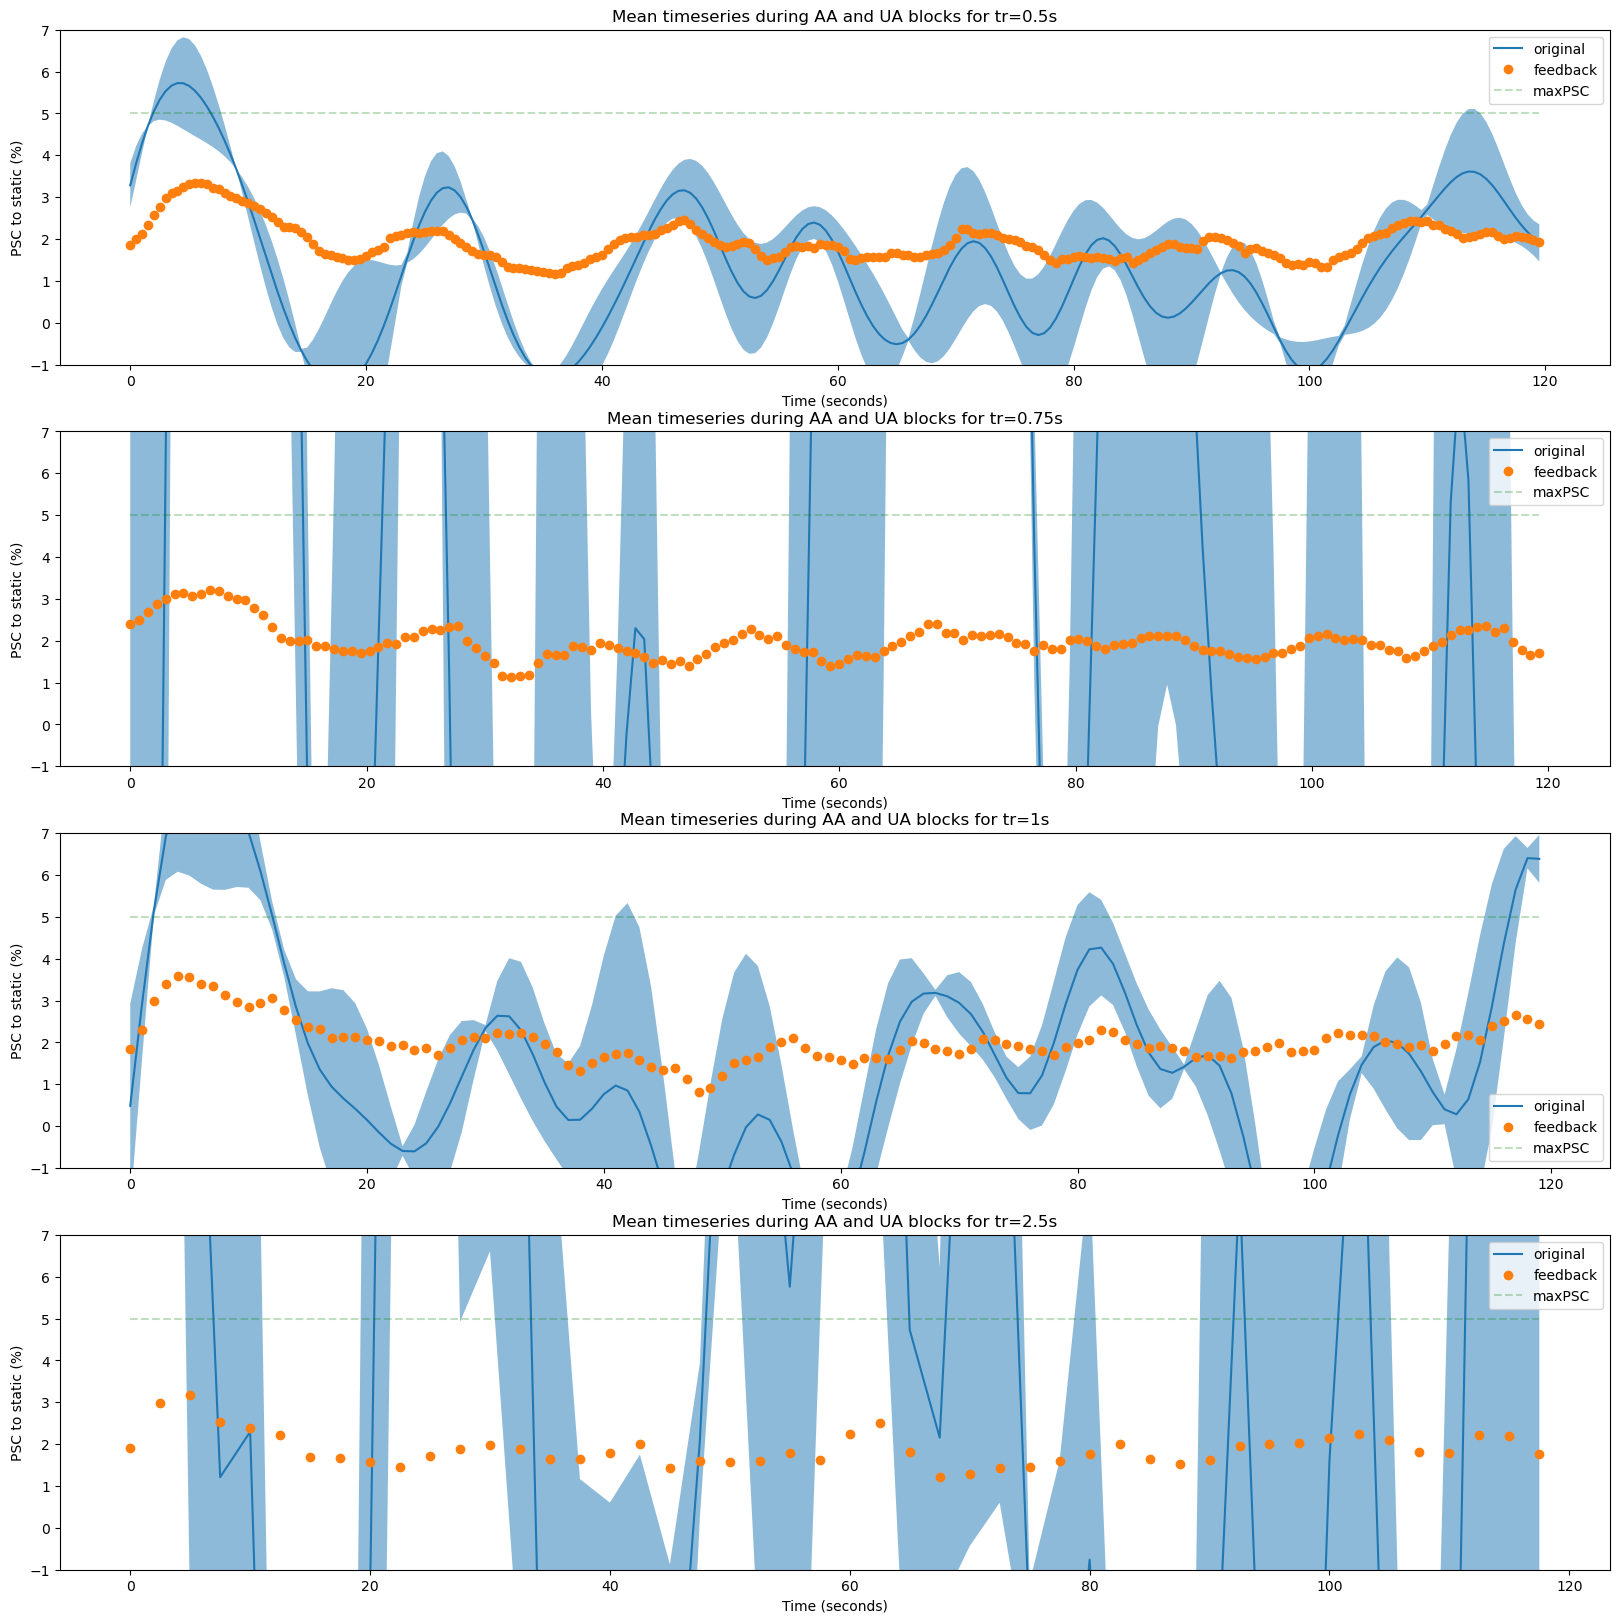

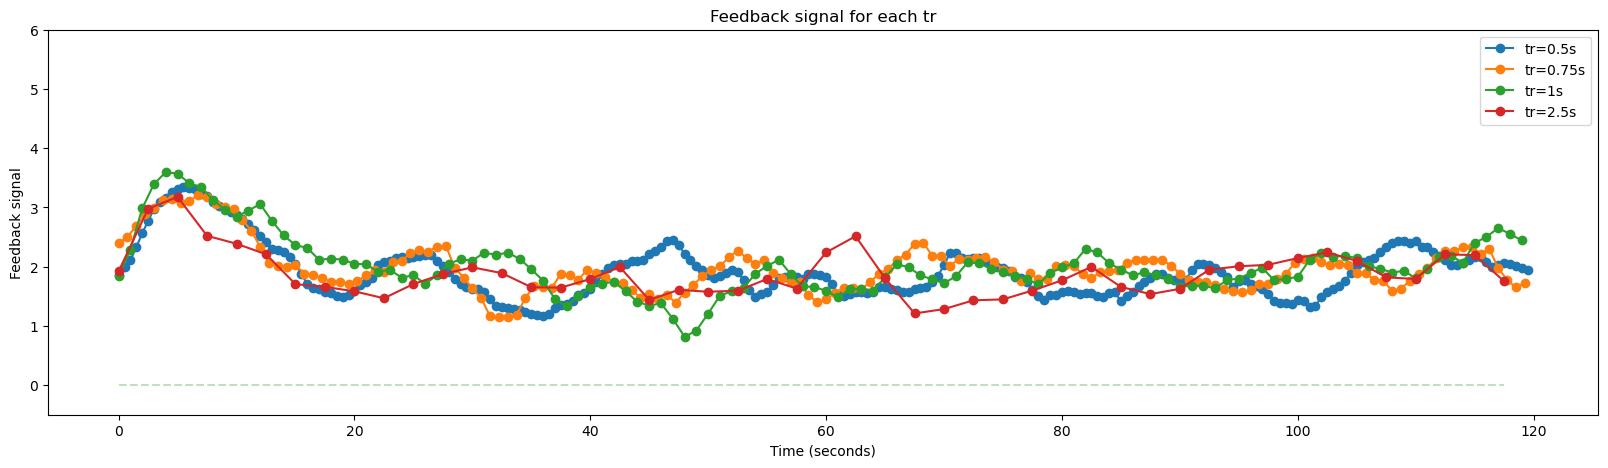

In [161]:
# plot feedback signal ERA with mean PSC to static timeseries for each tr
roi_name = 'right_v1'
max_psc = 5
f_psc, axs_psc = plt.subplots(4, 1, figsize=(20, 20))
f_feedback, axs_feedback = plt.subplots(figsize=(20, 5))

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros
    static_events_indexes_aux = static_events_indexes_arr[tr_idx,static_events_indexes_arr[tr_idx,:] > 0]
    active_events_indexes_aux = active_events_indexes_arr[tr_idx,active_events_indexes_arr[tr_idx,:] > 0]

    time_series = df[df['tr']==tr][roi_name]
    time_series = np.array(time_series.tolist()) # convert time_series to numpy array
    time_series_static = time_series[:,static_events_indexes_aux.astype(int)]

    # calculate mean of each row
    m = time_series_static.mean(axis=1)

    # substrat m from time_series and divide by abs(m)
    time_series_psc = (time_series - m[:,None]) / abs(m[:,None])

    # estimate mean psc
    time_series_psc_mean = time_series_psc.mean(axis=0)
    time_series_psc_std = time_series_psc.std(axis=0)

    # remap time_series_psc to feedback signal, limiting the max value to max_psc and the min value to 0
    time_series_psc_remap = time_series_psc.copy()
    time_series_psc_remap[time_series_psc_remap > max_psc] = max_psc
    time_series_psc_remap[time_series_psc_remap < 0] = 0

    # estimate mean psc for remapped time_series_psc
    time_series_psc_remap_mean = time_series_psc_remap.mean(axis=0)
    time_series_psc_remap_std = time_series_psc_remap.std(axis=0)

    # estimate event related response
    time_series_psc_mean_active = time_series_psc_mean[active_events_indexes_aux.astype(int)]
    time_series_psc_mean_active_length = time_series_psc_mean_active.shape[0]//2
    
    time_series_psc_remap_mean_active = time_series_psc_remap_mean[active_events_indexes_aux.astype(int)]

    # reshape time_series_psc_mean_active to two columns with half the points each
    time_series_psc_mean_active = time_series_psc_mean_active.reshape((2,time_series_psc_mean_active_length)).T
    time_series_psc_remap_mean_active = time_series_psc_remap_mean_active.reshape((2,time_series_psc_mean_active_length)).T

    # estimate mean and std over the two blocks
    time_series_psc_mean_psc_active_mean = time_series_psc_mean_active.mean(axis=1)
    time_series_psc_mean_psc_active_std = time_series_psc_mean_active.std(axis=1)

    time_series_psc_remap_mean_psc_active_mean = time_series_psc_remap_mean_active.mean(axis=1)
    time_series_psc_remap_mean_psc_active_std = time_series_psc_remap_mean_active.std(axis=1)

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, time_series_psc_mean_active_length*tr, tr)

    data_to_plot_std = time_series_psc_mean_psc_active_std

    # plot mean and std timeseries
    axs_psc[tr_idx].plot(time_vector, time_series_psc_mean_psc_active_mean)
    axs_psc[tr_idx].plot(time_vector, time_series_psc_remap_mean_psc_active_mean, linestyle='', marker='o')
    axs_psc[tr_idx].hlines(max_psc, 0, time_vector[-1], colors='g', linestyles='dashed', alpha=0.25)
    #axs_psc[tr_idx].hlines(-max_psc, 0, time_vector[-1], colors='g', linestyles='dashed', alpha=0.25)
    axs_psc[tr_idx].fill_between(time_vector, time_series_psc_mean_psc_active_mean-time_series_psc_mean_psc_active_std, time_series_psc_mean_psc_active_mean+time_series_psc_mean_psc_active_std, alpha=0.5)
    axs_psc[tr_idx].set_title('Mean timeseries during AA and UA blocks for tr='+str(tr)+'s')
    axs_psc[tr_idx].set_xlabel('Time (seconds)')
    axs_psc[tr_idx].set_ylabel('PSC to static (%)')
    axs_psc[tr_idx].set_ylim([-1, max_psc+2])
    axs_psc[tr_idx].legend(['original','feedback', 'maxPSC'])

    # plot feedback signal for this tr in figure_feedback
    axs_feedback.plot(time_vector, time_series_psc_remap_mean_psc_active_mean, linestyle='-', marker='o')

axs_feedback.hlines(0, 0, time_vector[-1], colors='g', linestyles='dashed', alpha=0.25)
axs_feedback.set_ylim([-0.5, max_psc+1])
axs_feedback.legend(['tr='+str(tr)+'s' for tr in tr_list],loc='upper right')
axs_feedback.set_title('Feedback signal for each tr')
axs_feedback.set_xlabel('Time (seconds)')
axs_feedback.set_ylabel('Feedback signal')